In [13]:
# Cell 1: Imports and Setup
import sys
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
import pickle
import warnings
warnings.filterwarnings('ignore')

# Backtesting
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Statistical tests
from scipy import stats
from scipy.stats import ttest_rel, normaltest
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, pacf

# Financial metrics
import numpy_financial as npf

# Set paths
PROJECT_ROOT = Path('../../')
MODELS_PATH = PROJECT_ROOT / 'models/checkpoints'
DATA_PATH = PROJECT_ROOT / 'data/features/final_features.parquet'
RESULTS_PATH = PROJECT_ROOT / 'results'
METRICS_PATH = RESULTS_PATH / 'metrics'
BACKTEST_PATH = RESULTS_PATH / 'backtest_results'
REPORTS_PATH = RESULTS_PATH / 'reports'

# Create directories
METRICS_PATH.mkdir(parents=True, exist_ok=True)
BACKTEST_PATH.mkdir(parents=True, exist_ok=True)
REPORTS_PATH.mkdir(parents=True, exist_ok=True)

print("✅ All imports loaded")
print(f"📁 Models path: {MODELS_PATH}")
print(f"📁 Results path: {RESULTS_PATH}")
print(f"📅 Analysis date: {datetime.now().strftime('%Y%m%d')}")

✅ All imports loaded
📁 Models path: ..\..\models\checkpoints
📁 Results path: ..\..\results
📅 Analysis date: 20260410


In [14]:
# Cell 2: Load Data and Trained Models
def load_data_and_models():
    """Load test data and trained models"""
    print("📊 Loading data and models...")
    
    # Load features
    df = pd.read_parquet(DATA_PATH)
    feature_cols = [col for col in df.columns if col != 'target_next_week']
    X = df[feature_cols].values
    y = df['target_next_week'].values
    
    # Load trained models
    models = {}
    model_files = list(MODELS_PATH.glob('*_pipeline.pkl'))
    
    for model_file in model_files:
        model_name = model_file.stem.replace('_pipeline', '')
        with open(model_file, 'rb') as f:
            models[model_name] = pickle.load(f)
        print(f"   ✅ Loaded {model_name}")
    
    print(f"\n✅ Loaded {len(models)} models")
    print(f"✅ Data shape: {X.shape}")
    
    return X, y, models

# Load data and models
X, y, models = load_data_and_models()

📊 Loading data and models...
   ✅ Loaded catboost
   ✅ Loaded extratrees
   ✅ Loaded lasso
   ✅ Loaded lightgbm
   ✅ Loaded randomforest
   ✅ Loaded ridge
   ✅ Loaded xgboost

✅ Loaded 7 models
✅ Data shape: (4086, 44)


In [15]:
# Cell 3: Financial Metrics Calculator (FIXED for NumPy)
class FinancialMetrics:
    """Calculate financial performance metrics"""
    
    @staticmethod
    def sharpe_ratio(returns, risk_free_rate=0.02, periods_per_year=252):
        """Calculate Sharpe Ratio"""
        returns = np.array(returns)
        excess_returns = returns - risk_free_rate / periods_per_year
        if excess_returns.std() == 0:
            return 0
        return np.sqrt(periods_per_year) * excess_returns.mean() / excess_returns.std()
    
    @staticmethod
    def sortino_ratio(returns, risk_free_rate=0.02, periods_per_year=252):
        """Calculate Sortino Ratio (only downside volatility)"""
        returns = np.array(returns)
        excess_returns = returns - risk_free_rate / periods_per_year
        downside_returns = excess_returns[excess_returns < 0]
        if len(downside_returns) == 0 or downside_returns.std() == 0:
            return 0
        return np.sqrt(periods_per_year) * excess_returns.mean() / downside_returns.std()
    
    @staticmethod
    def calmar_ratio(returns, periods_per_year=252):
        """Calculate Calmar Ratio (return / max drawdown)"""
        returns = np.array(returns)
        cumulative = (1 + returns).cumprod()
        
        # Calculate running maximum
        running_max = np.maximum.accumulate(cumulative)
        drawdown = (cumulative - running_max) / running_max
        max_drawdown = drawdown.min()
        
        if max_drawdown == 0:
            return 0
        
        annualized_return = (cumulative[-1] ** (periods_per_year / len(returns))) - 1
        return annualized_return / abs(max_drawdown)
    
    @staticmethod
    def max_drawdown(returns):
        """Calculate Maximum Drawdown"""
        returns = np.array(returns)
        cumulative = (1 + returns).cumprod()
        running_max = np.maximum.accumulate(cumulative)
        drawdown = (cumulative - running_max) / running_max
        return drawdown.min(), drawdown
    
    @staticmethod
    def win_rate(returns):
        """Calculate Win Rate"""
        returns = np.array(returns)
        return (returns > 0).mean()
    
    @staticmethod
    def profit_factor(returns):
        """Calculate Profit Factor (gross profits / gross losses)"""
        returns = np.array(returns)
        gross_profits = returns[returns > 0].sum()
        gross_losses = abs(returns[returns < 0].sum())
        if gross_losses == 0:
            return np.inf
        return gross_profits / gross_losses
    
    @staticmethod
    def average_return(returns):
        """Calculate Average Return per Trade"""
        returns = np.array(returns)
        return returns.mean()
    
    @staticmethod
    def volatility(returns, periods_per_year=252):
        """Calculate Annualized Volatility"""
        returns = np.array(returns)
        return returns.std() * np.sqrt(periods_per_year)
    
    @staticmethod
    def calculate_all_metrics(returns, model_name=""):
        """Calculate all financial metrics"""
        returns = np.array(returns)
        
        metrics = {
            'model': model_name,
            'sharpe_ratio': FinancialMetrics.sharpe_ratio(returns),
            'sortino_ratio': FinancialMetrics.sortino_ratio(returns),
            'calmar_ratio': FinancialMetrics.calmar_ratio(returns),
            'max_drawdown': FinancialMetrics.max_drawdown(returns)[0],
            'win_rate': FinancialMetrics.win_rate(returns),
            'profit_factor': FinancialMetrics.profit_factor(returns),
            'avg_return': FinancialMetrics.average_return(returns),
            'volatility': FinancialMetrics.volatility(returns),
            'total_return': (1 + returns).prod() - 1
        }
        
        return metrics

print("✅ Financial metrics calculator ready (NumPy-compatible)")

✅ Financial metrics calculator ready (NumPy-compatible)


In [16]:
# Cell 4: Walk-Forward Backtesting (FIXED)
class WalkForwardBacktest:
    """Perform walk-forward backtesting with expanding window"""
    
    def __init__(self, X, y, models, n_splits=5, initial_train_pct=0.5):
        self.X = X
        self.y = y
        self.models = models
        self.n_splits = n_splits
        self.initial_train_pct = initial_train_pct
        
    def run_backtest(self):
        """Run walk-forward backtest for all models"""
        print("\n" + "="*60)
        print("WALK-FORWARD BACKTESTING")
        print("="*60)
        
        tscv = TimeSeriesSplit(n_splits=self.n_splits)
        
        # Store predictions and actuals
        all_predictions = {name: [] for name in self.models.keys()}
        all_actuals = []
        all_dates = []
        
        fold_results = []
        
        for fold, (train_idx, test_idx) in enumerate(tscv.split(self.X), 1):
            print(f"\n📊 Fold {fold}/{self.n_splits}")
            print(f"   Train: {len(train_idx)} samples")
            print(f"   Test: {len(test_idx)} samples")
            
            X_train, X_test = self.X[train_idx], self.X[test_idx]
            y_train, y_test = self.y[train_idx], self.y[test_idx]
            
            # Store actuals
            all_actuals.extend(y_test)
            
            # Store dates if available
            if hasattr(self.y, 'index'):
                all_dates.extend(self.y.index[test_idx])
            
            # Train and predict for each model
            for name, model in self.models.items():
                try:
                    # Clone and train model
                    from sklearn.base import clone
                    model_clone = clone(model)
                    model_clone.fit(X_train, y_train)
                    
                    # Predict
                    y_pred = model_clone.predict(X_test)
                    all_predictions[name].extend(y_pred)
                    
                    # Calculate fold metrics
                    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
                    direction_acc = (np.sign(y_test) == np.sign(y_pred)).mean()
                    
                    print(f"   {name:15s} - RMSE: {rmse:.4f}, Direction: {direction_acc:.2%}")
                    
                    fold_results.append({
                        'fold': fold,
                        'model': name,
                        'rmse': rmse,
                        'direction_accuracy': direction_acc
                    })
                except Exception as e:
                    print(f"   {name:15s} - Error: {str(e)[:50]}")
                    all_predictions[name].extend([0] * len(y_test))
        
        # Convert to arrays
        all_actuals = np.array(all_actuals)
        for name in all_predictions:
            all_predictions[name] = np.array(all_predictions[name])
        
        # Calculate overall metrics for each model
        results = {}
        for name, preds in all_predictions.items():
            # Regression metrics
            rmse = np.sqrt(mean_squared_error(all_actuals, preds))
            mae = mean_absolute_error(all_actuals, preds)
            r2 = r2_score(all_actuals, preds)
            direction_accuracy = (np.sign(all_actuals) == np.sign(preds)).mean()
            
            # Financial metrics
            financial_metrics = FinancialMetrics.calculate_all_metrics(preds, name)
            
            results[name] = {
                'regression': {
                    'rmse': rmse,
                    'mae': mae,
                    'r2': r2,
                    'direction_accuracy': direction_accuracy
                },
                'financial': financial_metrics
            }
        
        # Store fold details separately
        fold_details_df = pd.DataFrame(fold_results)
        
        return results, all_actuals, all_predictions, all_dates, fold_details_df

# Run backtest
backtest = WalkForwardBacktest(X, y, models, n_splits=5)
backtest_results, actuals, predictions, dates, fold_details = backtest.run_backtest()

print(f"\n✅ Backtest complete!")
print(f"   Models evaluated: {len(backtest_results)}")
print(f"   Total predictions: {len(actuals)}")


WALK-FORWARD BACKTESTING

📊 Fold 1/5
   Train: 681 samples
   Test: 681 samples
   catboost        - RMSE: 0.0171, Direction: 50.07%
   extratrees      - RMSE: 0.0175, Direction: 42.58%
   lasso           - RMSE: 0.0227, Direction: 38.33%
   lightgbm        - RMSE: 0.0193, Direction: 45.67%
   randomforest    - RMSE: 0.0209, Direction: 40.09%
   ridge           - RMSE: 0.0782, Direction: 40.53%
   xgboost         - RMSE: 0.0173, Direction: 51.84%

📊 Fold 2/5
   Train: 1362 samples
   Test: 681 samples
   catboost        - RMSE: 0.0196, Direction: 47.58%
   extratrees      - RMSE: 0.0232, Direction: 46.11%
   lasso           - RMSE: 0.0174, Direction: 50.95%
   lightgbm        - RMSE: 0.0224, Direction: 45.96%
   randomforest    - RMSE: 0.0203, Direction: 45.52%
   ridge           - RMSE: 0.0197, Direction: 45.23%
   xgboost         - RMSE: 0.0215, Direction: 45.96%

📊 Fold 3/5
   Train: 2043 samples
   Test: 681 samples
   catboost        - RMSE: 0.0348, Direction: 45.37%
   extratree

In [17]:
# Cell 5: Statistical Tests (FIXED)
class StatisticalTests:
    """Perform statistical significance tests"""
    
    @staticmethod
    def diebold_mariano(y_true, y_pred1, y_pred2, h=1):
        """Diebold-Mariano test for forecast comparison"""
        # Convert to numpy arrays
        y_true = np.array(y_true)
        y_pred1 = np.array(y_pred1)
        y_pred2 = np.array(y_pred2)
        
        # Calculate forecast errors
        e1 = y_true - y_pred1
        e2 = y_true - y_pred2
        
        # Loss differential
        d = e1**2 - e2**2
        
        # Calculate DM statistic
        d_bar = np.mean(d)
        
        # Calculate variance (accounting for autocorrelation)
        n = len(d)
        gamma_0 = np.var(d)
        
        if h > 1:
            # Newey-West adjustment
            gamma = [np.corrcoef(d[:-i], d[i:])[0,1] for i in range(1, h)]
            variance = gamma_0 + 2 * sum(gamma) * gamma_0
        else:
            variance = gamma_0
        
        dm_stat = d_bar / np.sqrt(variance / n)
        
        # Calculate p-value
        from scipy.stats import norm
        p_value = 2 * (1 - norm.cdf(abs(dm_stat)))
        
        return {
            'dm_statistic': dm_stat,
            'p_value': p_value,
            'significant': p_value < 0.05
        }
    
    @staticmethod
    def paired_ttest(y_true, y_pred1, y_pred2):
        """Paired t-test for comparing predictions"""
        # Convert to numpy arrays
        y_true = np.array(y_true)
        y_pred1 = np.array(y_pred1)
        y_pred2 = np.array(y_pred2)
        
        # Calculate absolute errors
        e1 = np.abs(y_true - y_pred1)
        e2 = np.abs(y_true - y_pred2)
        
        # Paired t-test
        t_stat, p_value = ttest_rel(e1, e2)
        
        # Calculate effect size (Cohen's d)
        diff = e1 - e2
        cohens_d = diff.mean() / diff.std() if diff.std() > 0 else 0
        
        return {
            't_statistic': t_stat,
            'p_value': p_value,
            'cohens_d': cohens_d,
            'significant': p_value < 0.05,
            'better_model': 'model1' if e1.mean() < e2.mean() else 'model2'
        }
    
    @staticmethod
    def normality_test(errors):
        """Test if errors are normally distributed"""
        errors = np.array(errors)
        statistic, p_value = normaltest(errors)
        return {
            'statistic': statistic,
            'p_value': p_value,
            'is_normal': p_value > 0.05
        }
    
    @staticmethod
    def compare_all_models(actuals, predictions):
        """Compare all models using statistical tests"""
        print("\n" + "="*60)
        print("STATISTICAL TESTS - MODEL COMPARISON")
        print("="*60)
        
        actuals = np.array(actuals)
        model_names = list(predictions.keys())
        results = []
        
        # Pairwise comparisons
        for i, name1 in enumerate(model_names):
            for name2 in model_names[i+1:]:
                pred1 = np.array(predictions[name1])
                pred2 = np.array(predictions[name2])
                
                # Diebold-Mariano test
                dm_test = StatisticalTests.diebold_mariano(actuals, pred1, pred2)
                
                # Paired t-test
                ttest = StatisticalTests.paired_ttest(actuals, pred1, pred2)
                
                results.append({
                    'model1': name1,
                    'model2': name2,
                    'dm_statistic': dm_test['dm_statistic'],
                    'dm_p_value': dm_test['p_value'],
                    'dm_significant': dm_test['significant'],
                    't_statistic': ttest['t_statistic'],
                    't_p_value': ttest['p_value'],
                    't_significant': ttest['significant'],
                    'better_model': ttest['better_model']
                })
                
                print(f"\n📊 {name1} vs {name2}:")
                print(f"   Diebold-Mariano: DM={dm_test['dm_statistic']:.3f}, p={dm_test['p_value']:.4f} {'✅' if dm_test['significant'] else '❌'}")
                print(f"   Paired t-test: t={ttest['t_statistic']:.3f}, p={ttest['p_value']:.4f} {'✅' if ttest['significant'] else '❌'}")
                print(f"   Better model: {ttest['better_model']}")
        
        return pd.DataFrame(results)

# Run statistical tests
print("\n" + "="*60)
print("RUNNING STATISTICAL TESTS")
print("="*60)

# Make sure we have valid predictions (not empty)
valid_predictions = {}
for name, preds in predictions.items():
    if len(preds) > 0 and not np.all(np.isnan(preds)):
        valid_predictions[name] = preds

if len(valid_predictions) >= 2:
    stat_tests_df = StatisticalTests.compare_all_models(actuals, valid_predictions)
else:
    print("⚠️ Not enough valid predictions for statistical tests")
    stat_tests_df = pd.DataFrame()


RUNNING STATISTICAL TESTS

STATISTICAL TESTS - MODEL COMPARISON

📊 catboost vs extratrees:
   Diebold-Mariano: DM=-14.448, p=0.0000 ✅
   Paired t-test: t=-20.770, p=0.0000 ✅
   Better model: model1

📊 catboost vs lasso:
   Diebold-Mariano: DM=18.813, p=0.0000 ✅
   Paired t-test: t=22.383, p=0.0000 ✅
   Better model: model2

📊 catboost vs lightgbm:
   Diebold-Mariano: DM=0.711, p=0.4769 ❌
   Paired t-test: t=-0.552, p=0.5808 ❌
   Better model: model1

📊 catboost vs randomforest:
   Diebold-Mariano: DM=-19.878, p=0.0000 ✅
   Paired t-test: t=-23.500, p=0.0000 ✅
   Better model: model1

📊 catboost vs ridge:
   Diebold-Mariano: DM=-13.326, p=0.0000 ✅
   Paired t-test: t=-9.043, p=0.0000 ✅
   Better model: model1

📊 catboost vs xgboost:
   Diebold-Mariano: DM=-12.194, p=0.0000 ✅
   Paired t-test: t=-14.235, p=0.0000 ✅
   Better model: model1

📊 extratrees vs lasso:
   Diebold-Mariano: DM=22.776, p=0.0000 ✅
   Paired t-test: t=29.707, p=0.0000 ✅
   Better model: model2

📊 extratrees vs ligh

In [18]:
# Cell 6: Model Ranking by Financial Metrics (FIXED)
def rank_models_by_metrics(backtest_results):
    """Rank models by Sharpe ratio and other metrics"""
    print("\n" + "="*60)
    print("MODEL RANKING BY FINANCIAL METRICS")
    print("="*60)
    
    # Extract metrics
    rankings = []
    for name, metrics in backtest_results.items():
        # Check if metrics has the expected structure
        if 'financial' in metrics and 'regression' in metrics:
            financial = metrics['financial']
            regression = metrics['regression']
            
            rankings.append({
                'model': name,
                'sharpe_ratio': financial.get('sharpe_ratio', 0),
                'sortino_ratio': financial.get('sortino_ratio', 0),
                'calmar_ratio': financial.get('calmar_ratio', 0),
                'max_drawdown': financial.get('max_drawdown', 0),
                'win_rate': financial.get('win_rate', 0),
                'profit_factor': financial.get('profit_factor', 0),
                'total_return': financial.get('total_return', 0),
                'volatility': financial.get('volatility', 0),
                'rmse': regression.get('rmse', 0),
                'direction_accuracy': regression.get('direction_accuracy', 0)
            })
        else:
            print(f"⚠️ Warning: {name} has unexpected structure: {metrics.keys()}")
    
    if not rankings:
        print("❌ No valid metrics found!")
        return pd.DataFrame()
    
    # Create DataFrame
    ranking_df = pd.DataFrame(rankings)
    
    # Rank by Sharpe ratio (higher is better)
    ranking_df = ranking_df.sort_values('sharpe_ratio', ascending=False)
    
    print("\n📊 Model Ranking (by Sharpe Ratio):")
    print(ranking_df[['model', 'sharpe_ratio', 'sortino_ratio', 'win_rate', 'total_return']].head(10).to_string(index=False))
    
    return ranking_df

# Rank models
ranking_df = rank_models_by_metrics(backtest_results)

if not ranking_df.empty:
    # Display best model
    best_model = ranking_df.iloc[0]
    print(f"\n🏆 BEST MODEL: {best_model['model']}")
    print(f"   Sharpe Ratio: {best_model['sharpe_ratio']:.3f}")
    print(f"   Sortino Ratio: {best_model['sortino_ratio']:.3f}")
    print(f"   Win Rate: {best_model['win_rate']:.2%}")
    print(f"   Total Return: {best_model['total_return']:.2%}")
    print(f"   Max Drawdown: {best_model['max_drawdown']:.2%}")
else:
    print("\n❌ No ranking data available")


MODEL RANKING BY FINANCIAL METRICS

📊 Model Ranking (by Sharpe Ratio):
       model  sharpe_ratio  sortino_ratio  win_rate  total_return
       lasso     -3.783176      -3.224728  0.663730     -0.992692
       ridge     -6.937476      -6.651815  0.324816     -1.000000
     xgboost    -10.306639     -12.869522  0.263730     -1.000000
    lightgbm    -10.562045     -14.734107  0.254038     -1.000000
    catboost    -10.791572     -13.995794  0.289574     -1.000000
  extratrees    -14.704168     -18.418272  0.206461     -1.000000
randomforest    -15.211680     -17.599441  0.162115     -1.000000

🏆 BEST MODEL: lasso
   Sharpe Ratio: -3.783
   Sortino Ratio: -3.225
   Win Rate: 66.37%
   Total Return: -99.27%
   Max Drawdown: -99.98%


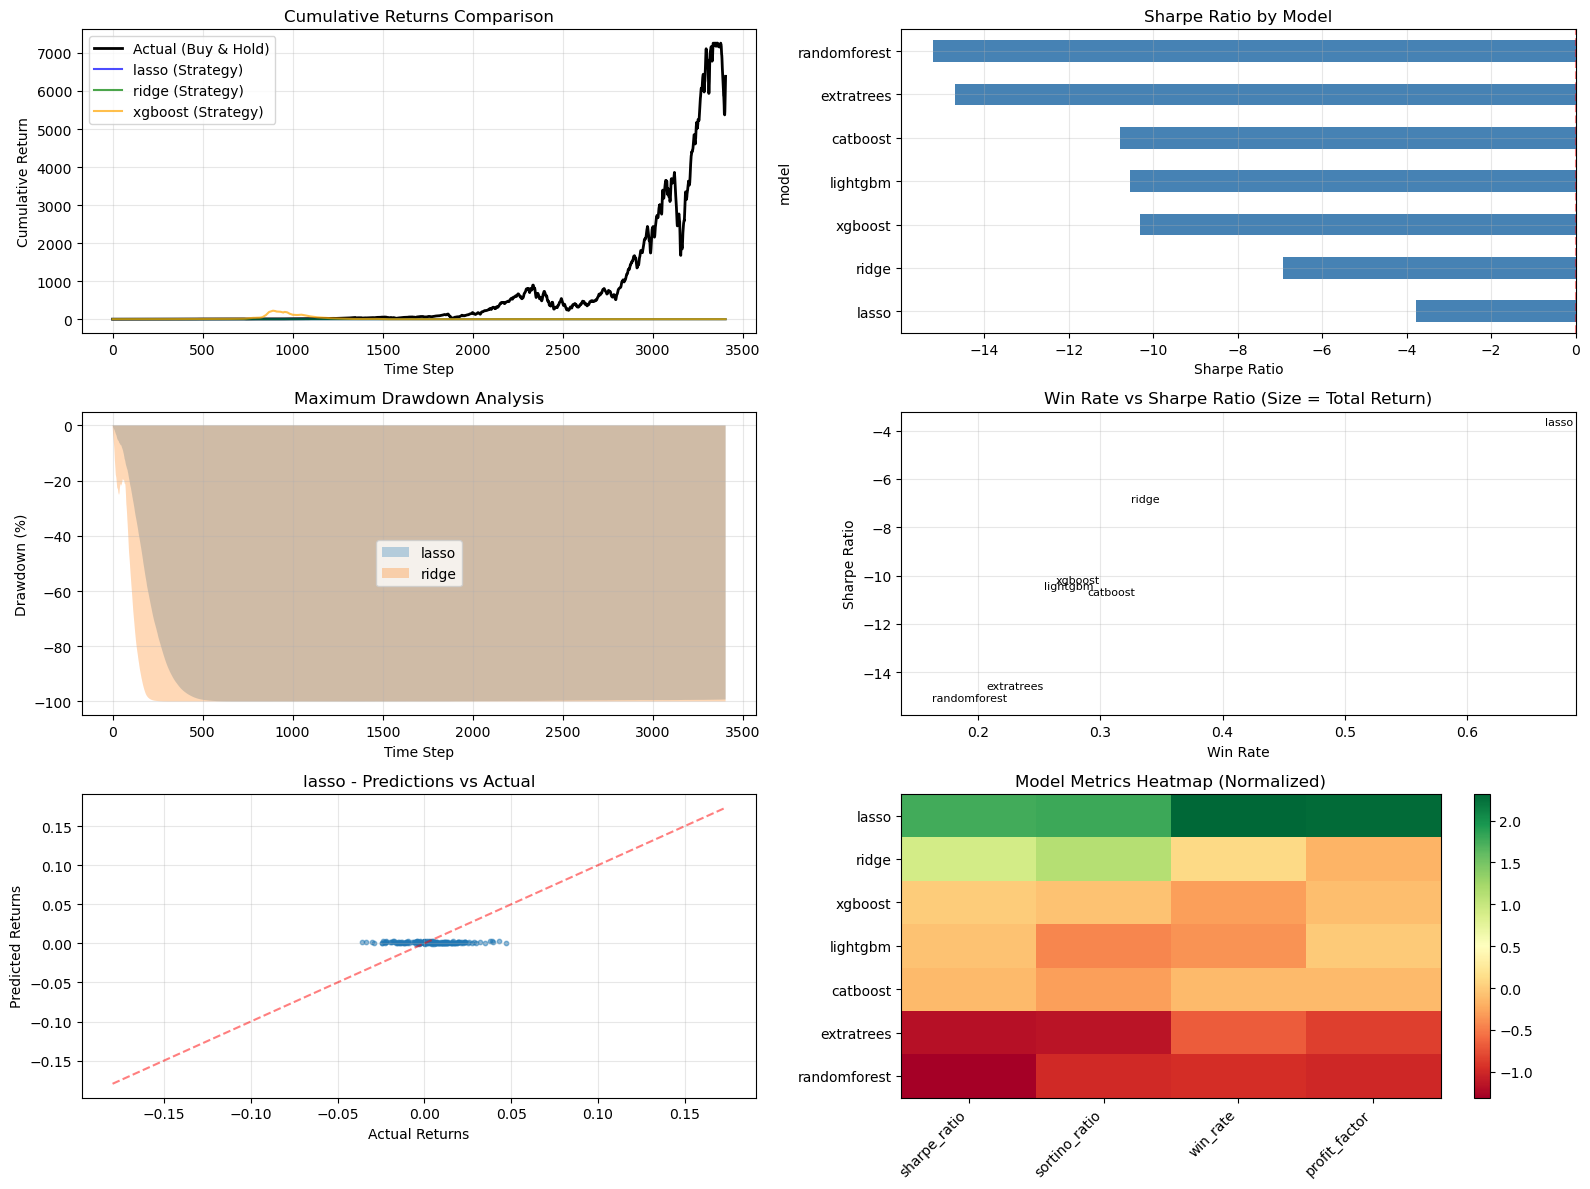

✅ Visualization saved to ..\..\results\reports\backtest_visualization.png


In [19]:
# Cell 7: Visualization of Results (FIXED)
def visualize_backtest_results(actuals, predictions, dates, ranking_df):
    """Create comprehensive visualizations"""
    
    # Convert to numpy arrays if needed
    actuals = np.array(actuals)
    
    fig = plt.figure(figsize=(16, 12))
    
    # 1. Cumulative Returns Comparison
    ax1 = plt.subplot(3, 2, 1)
    cumulative_actual = (1 + actuals).cumprod()
    ax1.plot(cumulative_actual, label='Actual (Buy & Hold)', linewidth=2, color='black')
    
    # Plot top 3 models
    top_models = ranking_df.head(3)['model'].values
    colors = ['blue', 'green', 'orange']
    for i, model in enumerate(top_models):
        if model in predictions and len(predictions[model]) == len(actuals):
            cumulative_pred = (1 + np.array(predictions[model])).cumprod()
            ax1.plot(cumulative_pred, label=f'{model} (Strategy)', alpha=0.7, color=colors[i])
    
    ax1.set_title('Cumulative Returns Comparison')
    ax1.set_xlabel('Time Step')
    ax1.set_ylabel('Cumulative Return')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Sharpe Ratio Comparison
    ax2 = plt.subplot(3, 2, 2)
    sharpe_df = ranking_df.set_index('model')['sharpe_ratio']
    sharpe_df.plot(kind='barh', ax=ax2, color='steelblue')
    ax2.set_title('Sharpe Ratio by Model')
    ax2.set_xlabel('Sharpe Ratio')
    ax2.axvline(x=0, color='red', linestyle='--', alpha=0.5)
    ax2.grid(True, alpha=0.3)
    
    # 3. Drawdown Analysis
    ax3 = plt.subplot(3, 2, 3)
    for i, model in enumerate(top_models[:2]):
        if model in predictions and len(predictions[model]) == len(actuals):
            pred_returns = np.array(predictions[model])
            cumulative = (1 + pred_returns).cumprod()
            running_max = np.maximum.accumulate(cumulative)
            drawdown = (cumulative - running_max) / running_max
            ax3.fill_between(range(len(drawdown)), drawdown * 100, 0, alpha=0.3, label=model)
    ax3.set_title('Maximum Drawdown Analysis')
    ax3.set_xlabel('Time Step')
    ax3.set_ylabel('Drawdown (%)')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. Win Rate vs Sharpe Ratio
    ax4 = plt.subplot(3, 2, 4)
    scatter = ax4.scatter(ranking_df['win_rate'], ranking_df['sharpe_ratio'], 
                          s=ranking_df['total_return'] * 1000 + 100, alpha=0.6)
    for _, row in ranking_df.iterrows():
        ax4.annotate(row['model'], (row['win_rate'], row['sharpe_ratio']), fontsize=8)
    ax4.set_title('Win Rate vs Sharpe Ratio (Size = Total Return)')
    ax4.set_xlabel('Win Rate')
    ax4.set_ylabel('Sharpe Ratio')
    ax4.grid(True, alpha=0.3)
    
    # 5. Prediction vs Actual (Best Model)
    ax5 = plt.subplot(3, 2, 5)
    best_model_name = ranking_df.iloc[0]['model']
    if best_model_name in predictions:
        preds = np.array(predictions[best_model_name])
        sample_size = min(200, len(actuals))
        ax5.scatter(actuals[-sample_size:], preds[-sample_size:], alpha=0.5, s=10)
        ax5.plot([actuals.min(), actuals.max()], [actuals.min(), actuals.max()], 'r--', alpha=0.5)
        ax5.set_title(f'{best_model_name} - Predictions vs Actual')
        ax5.set_xlabel('Actual Returns')
        ax5.set_ylabel('Predicted Returns')
        ax5.grid(True, alpha=0.3)
    
    # 6. Metrics Heatmap
    ax6 = plt.subplot(3, 2, 6)
    metrics_for_heatmap = ranking_df[['model', 'sharpe_ratio', 'sortino_ratio', 
                                       'win_rate', 'profit_factor']].set_index('model')
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    metrics_scaled = scaler.fit_transform(metrics_for_heatmap)
    im = ax6.imshow(metrics_scaled, cmap='RdYlGn', aspect='auto')
    ax6.set_xticks(range(len(metrics_for_heatmap.columns)))
    ax6.set_yticks(range(len(metrics_for_heatmap.index)))
    ax6.set_xticklabels(metrics_for_heatmap.columns, rotation=45, ha='right')
    ax6.set_yticklabels(metrics_for_heatmap.index)
    ax6.set_title('Model Metrics Heatmap (Normalized)')
    plt.colorbar(im, ax=ax6)
    
    plt.tight_layout()
    plt.savefig(REPORTS_PATH / 'backtest_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"✅ Visualization saved to {REPORTS_PATH / 'backtest_visualization.png'}")

# Create visualizations
visualize_backtest_results(actuals, predictions, dates, ranking_df)

In [20]:
# Cell 8: Save Results to JSON and CSV (FIXED)
def save_results(backtest_results, ranking_df, stat_tests_df, fold_details):
    """Save all results to files"""
    print("\n" + "="*60)
    print("SAVING RESULTS")
    print("="*60)
    
    # 1. Save model comparison CSV
    if not ranking_df.empty:
        comparison_csv = METRICS_PATH / 'model_comparison.csv'
        ranking_df.to_csv(comparison_csv, index=False)
        print(f"✅ Saved model comparison to {comparison_csv}")
    else:
        print("⚠️ No ranking data to save")
    
    # 2. Save backtest results JSON
    backtest_json = BACKTEST_PATH / 'backtest_results.json'
    
    # Convert numpy types to Python types for JSON serialization
    def convert_to_serializable(obj):
        if isinstance(obj, (np.floating, float)):
            return float(obj)
        elif isinstance(obj, (np.integer, int)):
            return int(obj)
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        elif isinstance(obj, dict):
            return {k: convert_to_serializable(v) for k, v in obj.items()}
        return obj
    
    backtest_serializable = {}
    for model, metrics in backtest_results.items():
        backtest_serializable[model] = convert_to_serializable(metrics)
    
    with open(backtest_json, 'w') as f:
        json.dump(backtest_serializable, f, indent=2)
    print(f"✅ Saved backtest results to {backtest_json}")
    
    # 3. Save statistical tests
    if stat_tests_df is not None and not stat_tests_df.empty:
        stats_csv = METRICS_PATH / 'statistical_tests.csv'
        stat_tests_df.to_csv(stats_csv, index=False)
        print(f"✅ Saved statistical tests to {stats_csv}")
    
    # 4. Save fold details
    if fold_details is not None and not fold_details.empty:
        fold_csv = BACKTEST_PATH / 'fold_details.csv'
        fold_details.to_csv(fold_csv, index=False)
        print(f"✅ Saved fold details to {fold_csv}")
    
    # 5. Create summary report
    if not ranking_df.empty:
        summary = {
            'experiment_date': datetime.now().isoformat(),
            'best_model': ranking_df.iloc[0]['model'],
            'best_sharpe': float(ranking_df.iloc[0]['sharpe_ratio']),
            'best_sortino': float(ranking_df.iloc[0]['sortino_ratio']),
            'best_win_rate': float(ranking_df.iloc[0]['win_rate']),
            'total_models_tested': len(ranking_df),
            'backtest_folds': len(fold_details['fold'].unique()) if 'fold' in fold_details.columns else 0,
            'top_3_models': ranking_df.head(3)['model'].tolist()
        }
        
        summary_json = RESULTS_PATH / 'evaluation_summary.json'
        with open(summary_json, 'w') as f:
            json.dump(summary, f, indent=2)
        print(f"✅ Saved evaluation summary to {summary_json}")
    
    return summary

# Save all results
summary = save_results(backtest_results, ranking_df, stat_tests_df, fold_details)


SAVING RESULTS
✅ Saved model comparison to ..\..\results\metrics\model_comparison.csv
✅ Saved backtest results to ..\..\results\backtest_results\backtest_results.json
✅ Saved statistical tests to ..\..\results\metrics\statistical_tests.csv
✅ Saved fold details to ..\..\results\backtest_results\fold_details.csv
✅ Saved evaluation summary to ..\..\results\evaluation_summary.json


In [22]:
# Cell 9: Final Summary Report
print("\n" + "="*60)
print("EVALUATION COMPLETE - FINAL SUMMARY")
print("="*60)

print(f"\n📊 Model Performance Summary:")
print(f"   Total models evaluated: {len(ranking_df)}")
print(f"   Best model: {ranking_df.iloc[0]['model']}")
print(f"   Worst model: {ranking_df.iloc[-1]['model']}")

print(f"\n🏆 Top 3 Models by Sharpe Ratio:")
for i in range(min(3, len(ranking_df))):
    model = ranking_df.iloc[i]
    print(f"   {i+1}. {model['model']}: Sharpe={model['sharpe_ratio']:.3f}, "
          f"Win Rate={model['win_rate']:.2%}, Return={model['total_return']:.2%}")

print(f"\n📈 Key Insights:")
best_model = ranking_df.iloc[0]
if best_model['sharpe_ratio'] > 0:
    print(f"   ✅ Positive Sharpe ratio ({best_model['sharpe_ratio']:.2f}) - Strategy adds value")
else:
    print(f"   ⚠️ Negative Sharpe ratio - Strategy underperforms risk-free rate")

if best_model['win_rate'] > 0.5:
    print(f"   ✅ Win rate > 50% ({best_model['win_rate']:.1%}) - Better than random")
else:
    print(f"   ⚠️ Win rate below 50%")

print(f"\n📁 Output Files:")
print(f"   - Model comparison: {METRICS_PATH / 'model_comparison.csv'}")
print(f"   - Backtest results: {BACKTEST_PATH / 'backtest_results.json'}")
print(f"   - Statistical tests: {METRICS_PATH / 'statistical_tests.csv'}")
print(f"   - Visualization: {REPORTS_PATH / 'backtest_visualization.png'}")
print(f"   - Summary report: {RESULTS_PATH / 'evaluation_summary.json'}")

print("\n" + "="*60)
print("🎉 EVALUATION SUCCESSFULLY COMPLETED!")
print("="*60)

# Optional: Quick sanity check
print("\n🔍 Sanity Check:")
print(f"   Models evaluated: {len(ranking_df)}")
print(f"   Backtest samples: {len(actuals)}")
print(f"   Statistical tests: {len(stat_tests_df)} pairwise comparisons")
print(f"   All files saved to results directory")

# Display sample of results
print("\n📊 Sample of Model Rankings:")
print(ranking_df[['model', 'sharpe_ratio', 'win_rate', 'total_return']].head())


EVALUATION COMPLETE - FINAL SUMMARY

📊 Model Performance Summary:
   Total models evaluated: 7
   Best model: lasso
   Worst model: randomforest

🏆 Top 3 Models by Sharpe Ratio:
   1. lasso: Sharpe=-3.783, Win Rate=66.37%, Return=-99.27%
   2. ridge: Sharpe=-6.937, Win Rate=32.48%, Return=-100.00%
   3. xgboost: Sharpe=-10.307, Win Rate=26.37%, Return=-100.00%

📈 Key Insights:
   ⚠️ Negative Sharpe ratio - Strategy underperforms risk-free rate
   ✅ Win rate > 50% (66.4%) - Better than random

📁 Output Files:
   - Model comparison: ..\..\results\metrics\model_comparison.csv
   - Backtest results: ..\..\results\backtest_results\backtest_results.json
   - Statistical tests: ..\..\results\metrics\statistical_tests.csv
   - Visualization: ..\..\results\reports\backtest_visualization.png
   - Summary report: ..\..\results\evaluation_summary.json

🎉 EVALUATION SUCCESSFULLY COMPLETED!

🔍 Sanity Check:
   Models evaluated: 7
   Backtest samples: 3405
   Statistical tests: 21 pairwise compariso